# Étape 4 - Apprentissage semi-supervisé

**Projet BrainScanAI** - Détection de tumeurs cérébrales  
Objectif : entraîner un classifieur sur les données faiblement labelisées, puis affiner sur les données fortement labelisées. Comparer les performances avec un modèle supervisé pur.

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Ajout de la racine du projet au chemin Python pour importer src/
sys.path.append(str(Path("..").resolve())) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch -- framework pour construire et entraîner le modèle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    fbeta_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("Imports OK")
print(f"PyTorch version : {torch.__version__}")

Imports OK
PyTorch version : 2.2.2+cpu


## 2. Configuration

In [2]:
from src.config import PROCESSED_DIR, FEATURES_DIR, RESULTS_DIR, RANDOM_STATE, DEVICE

# Hyperparamètres du modèle 
INPUT_DIM      = 2048   # Taille du vecteur de features ResNet50
HIDDEN_DIM     = 512    # Neurones dans la première couche cachée
N_CLASSES      = 2      # Cancer ou normal
DROPOUT        = 0.4    # Taux de dropout pour régulariser (éviter le sur-apprentissage)

# Hyperparamètres d'entraînement
LR_INIT        = 1e-3   # Taux d'apprentissage initial (phase 1 et modèle A)
LR_FINETUNE    = 1e-4   # Taux d'apprentissage réduit pour le fine-tuning (phase 2)
EPOCHS_A       = 50     # Epochs pour le modèle supervisé pur
EPOCHS_WEAK    = 30     # Epochs pour la phase 1 semi-supervisée (labels faibles)
EPOCHS_STRONG  = 30     # Epochs pour la phase 2 semi-supervisée (fine-tuning)
BATCH_SMALL    = 16     # Batch size pour les petits datasets (80 images)
BATCH_LARGE    = 64     # Batch size pour les grands datasets (1486 images)

torch.manual_seed(RANDOM_STATE)  # Reproductibilité des poids initiaux

print(f"Appareil : {DEVICE}")
print(f"Graine   : {RANDOM_STATE}")

Appareil : cpu
Graine   : 42


## 3. Chargement des données

In [3]:
# Chargement de la matrice de features brutes (1506, 2048) -- non standardisées
features_raw = np.load(FEATURES_DIR / "resnet50_features.npy")

# Métadonnées avec weak labels DBSCAN (produit par l'étape 3)
# Colonnes : path, label, split, weak_label_dbscan, cluster_dbscan
meta = pd.read_csv(PROCESSED_DIR / "metadata_weak_labels_dbscan.csv")

# Test set de 20 images avec vrais labels (isolé à l'étape 2)
test_meta = pd.read_csv(PROCESSED_DIR / "test_set.csv")

# Features augmentées -- 80 images × 9 augmentations = 720 images (produit par l'étape 2) 
features_aug_raw = np.load(FEATURES_DIR / "resnet50_features_augmented.npy")
meta_aug = pd.read_csv(FEATURES_DIR / "resnet50_metadata_augmented.csv")

print(f"Features originales     : {features_raw.shape}")
print(f"Métadonnées             : {meta.shape}")
print(f"Test set                : {test_meta.shape}")
print(f"Features augmentées     : {features_aug_raw.shape}")
print(f"Métadonnées augmentées  : {meta_aug.shape}")
print(f"\nDistribution weak_label_dbscan :")
print(meta["weak_label_dbscan"].value_counts())

Features originales     : (1506, 2048)
Métadonnées             : (1506, 5)
Test set                : (20, 3)
Features augmentées     : (720, 2048)
Métadonnées augmentées  : (720, 4)

Distribution weak_label_dbscan :
weak_label_dbscan
cancer    845
normal    661
Name: count, dtype: int64


In [4]:
meta.head()

,path,label,split,weak_label_dbscan,cluster_dbscan
0,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled,cancer,0
1,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled,normal,1
2,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled,normal,1
3,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled,cancer,2
4,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled,cancer,2


In [5]:
test_meta.head()

,path,label,split
0,C:\Users\fkhellad\Formation_IA\Projet7_mission...,normal,labeled
1,C:\Users\fkhellad\Formation_IA\Projet7_mission...,normal,labeled
2,C:\Users\fkhellad\Formation_IA\Projet7_mission...,normal,labeled
3,C:\Users\fkhellad\Formation_IA\Projet7_mission...,normal,labeled
4,C:\Users\fkhellad\Formation_IA\Projet7_mission...,cancer,labeled


In [6]:
# Séparation train / test par correspondance de chemins
test_paths = set(test_meta["path"].values)
is_test    = meta["path"].isin(test_paths).values

features_train_all = features_raw[~is_test]   # (1486, 2048) -- images non-test
features_test      = features_raw[is_test]    # (20, 2048)   -- test set
meta_train         = meta[~is_test].reset_index(drop=True)
meta_test          = meta[is_test].reset_index(drop=True)

labels_test = (meta_test["label"] == "cancer").astype(int).values

# Sous-ensemble des 80 images fortement labelisées (hors test)
is_strong       = meta_train["label"].notna().values
features_strong = features_train_all[is_strong]
labels_strong   = (meta_train[is_strong]["label"] == "cancer").astype(int).values

# Labels pour les 1486 images -- modèle B (DBSCAN weak labels)
# Vrai label si connu, sinon label faible DBSCAN 
labels_all_train_dbscan = np.where(
    meta_train["label"].notna(),
    (meta_train["label"] == "cancer").astype(int),
    (meta_train["weak_label_dbscan"] == "cancer").astype(int)
)

# Données augmentées pour le modèle C -- 720 images (80 × 9 augmentations)
# Le split a été effectué à l'étape 2 : toutes les augmentations sont issues du train set
features_aug_train = features_aug_raw                                          # (720, 2048)
labels_aug_train   = (meta_aug["label"] == "cancer").astype(int).values        # vrais labels

print(f"Images train (originales)    : {features_train_all.shape[0]}")
print(f"  Fortement labelisées       : {is_strong.sum()}")
print(f"  Faiblement labelisées      : {(~is_strong).sum()}")
print(f"Images augmentées (train)    : {features_aug_train.shape[0]}")
print(f"Images test                  : {features_test.shape[0]}")
print(f"\nTotal modèle C               : {features_train_all.shape[0] + features_aug_train.shape[0]}")

Images train (originales)    : 1486
  Fortement labelisées       : 80
  Faiblement labelisées      : 1406
Images augmentées (train)    : 720
Images test                  : 20

Total modèle C               : 2206


## 4. Standardisation

StandardScaler entraîné sans le test set - éviter le data leakage.

In [7]:
# Entraînement du scaler sur les 1486 images non-test uniquement 
scaler = StandardScaler()
scaler.fit(features_train_all)

# Application à toutes les données
features_train_scaled     = scaler.transform(features_train_all)  # (1486, 2048)
features_strong_scaled    = scaler.transform(features_strong)     # (80, 2048)
features_aug_train_scaled = scaler.transform(features_aug_train)  # (~720, 2048)
features_test_scaled      = scaler.transform(features_test)       # (20, 2048)

print(f"Après standardisation -- moyenne : {features_train_scaled.mean():.4f}, std : {features_train_scaled.std():.4f}")

Après standardisation -- moyenne : 0.0000, std : 1.0000


## 5. Dataset PyTorch

PyTorch nécessite une classe `Dataset` pour charger les données par lots (batches).

In [8]:
class FeaturesDataset(Dataset):
    """Dataset PyTorch pour des vecteurs de features numériques."""

    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels   = torch.LongTensor(labels)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# --- Modèle A : 80 images fortement labelisées ---
dataset_strong = FeaturesDataset(features_strong_scaled, labels_strong)

# --- Modèle B : 1486 images avec DBSCAN weak labels ---
dataset_all_dbscan = FeaturesDataset(features_train_scaled, labels_all_train_dbscan)

# --- Modèle C : 1486 DBSCAN + ~720 augmentées = ~2206 images ---
features_all_aug = np.vstack([features_train_scaled, features_aug_train_scaled])
labels_all_aug   = np.concatenate([labels_all_train_dbscan, labels_aug_train])
dataset_all_aug  = FeaturesDataset(features_all_aug, labels_all_aug)

# --- Test set ---
dataset_test = FeaturesDataset(features_test_scaled, labels_test)

# DataLoaders
loader_strong     = DataLoader(dataset_strong,     batch_size=BATCH_SMALL, shuffle=True)
loader_all_dbscan = DataLoader(dataset_all_dbscan, batch_size=BATCH_LARGE, shuffle=True)
loader_all_aug    = DataLoader(dataset_all_aug,    batch_size=BATCH_LARGE, shuffle=True)
loader_test       = DataLoader(dataset_test,       batch_size=BATCH_SMALL, shuffle=False)

print(f"Dataset A -- supervisé pur      : {len(dataset_strong)} images")
print(f"Dataset B -- DBSCAN weak labels : {len(dataset_all_dbscan)} images")
print(f"Dataset C -- DBSCAN + augmenté  : {len(dataset_all_aug)} images")
print(f"Dataset test                    : {len(dataset_test)} images")

Dataset A -- supervisé pur      : 80 images
Dataset B -- DBSCAN weak labels : 1486 images
Dataset C -- DBSCAN + augmenté  : 2206 images
Dataset test                    : 20 images


## 6. Architecture du modèle MLP

- **BatchNorm** : normalise les activations pour stabiliser l'entraînement
- **Dropout** : désactive aléatoirement des neurones pendant l'entraînement pour éviter le sur-apprentissage
- **ReLU** : fonction d'activation qui introduit de la non-linéarité (sans elle, le réseau serait équivalent à une régression linéaire)

In [ ]:
class MLPClassifier(nn.Module):
    """Classifieur MLP sur les features ResNet50."""

    def __init__(self, input_dim=2048, hidden_dim=512, n_classes=2, dropout=0.4):
        super().__init__()
        self.network = nn.Sequential(
            # Première couche : 2048 -> 512
            nn.Linear(input_dim, hidden_dim),    # couche dense : 2048 entrées -> 512 sorties
            nn.BatchNorm1d(hidden_dim),          # normalise les 512 activations (moyenne 0, variance 1)
            nn.ReLU(),                           # active : max(0, x), introduit la non-linéarité
            nn.Dropout(dropout),                 # désactive aléatoirement 40% des neurones (anti-overfitting)


            # Deuxième couche : 512 -> 128
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.75), # désactive aléatoirement 30% des neurones (anti-overfitting)

            # Couche de sortie : 128 -> 2 (cancer ou normal)
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.network(x)


# Instanciation pour vérification de l'architecture
model_test = MLPClassifier(INPUT_DIM, HIDDEN_DIM, N_CLASSES, DROPOUT)
print(model_test)
n_params = sum(p.numel() for p in model_test.parameters())
print(f"\nNombre de paramètres : {n_params:,}")

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.30000000000000004, inplace=False)
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)

Nombre de paramètres : 1,116,290


## 7. Fonctions d'entraînement et d'évaluation

In [10]:
def train_model(model, loader, optimizer, criterion, device, n_epochs, desc=""):
    """Entraînement du modèle sur un nombre d'epochs donné."""
    model.train()
    losses = []
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for features, labels in loader:
            features = features.to(device)
            labels   = labels.to(device)

            optimizer.zero_grad()          # Remise à zéro des gradients
            outputs = model(features)      # Prédiction du modèle
            loss    = criterion(outputs, labels)  # Calcul de l'erreur entre prédictions et vrais labels
            loss.backward()                # calcul du gradient de l'erreur par rapport à chaque poids
            optimizer.step()               # Mise à jour des poids dans la direction qui réduit l'erreur, selon le gradient et le learning rate

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"  {desc} Epoch {epoch+1:3d}/{n_epochs} -- Loss : {avg_loss:.4f}")

    return losses


def evaluate_model(model, loader, device):
    """Évaluation du modèle : retourne vrais labels, prédictions et probabilités de la classe cancer."""
    model.eval()
    all_preds  = []
    all_labels = []
    all_probas = []
    with torch.no_grad():  # Désactivation du calcul des gradients (mode inférence)
        for features, labels in loader:
            features = features.to(device)
            outputs  = model(features)
            probas   = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # probabilité de la classe cancer
            preds    = torch.argmax(outputs, dim=1).cpu().numpy()  # Classe avec le score le plus haut
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probas.extend(probas)
    return np.array(all_labels), np.array(all_preds), np.array(all_probas)


def print_metrics(y_true, y_pred, y_proba, model_name):
    """Affichage des métriques de classification."""
    acc = accuracy_score(y_true, y_pred)
    f2  = fbeta_score(y_true, y_pred, beta=2, average="macro")  # poids du rappel x2 -- réduire les FN
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n{'='*40}")
    print(f"Modèle : {model_name}")
    print(f"  Accuracy (exactitude) : {acc:.4f}")
    print(f"  F2-score (macro)      : {f2:.4f}")
    print(f"  ROC-AUC               : {auc:.4f}")
    print(f"{'='*40}")
    print(classification_report(y_true, y_pred, target_names=["normal", "cancer"]))
    return acc, f2, auc


print("Fonctions définies.")

Fonctions définies.


## 8. Modèle A - Supervisé pur (baseline)

Entraînement uniquement sur les **80 images fortement labelisées**.  
C'est la méthode classique supervisée -- elle sert de référence pour mesurer l'apport du semi-supervisé.

In [11]:
# Initialisation du modèle A
model_A    = MLPClassifier(INPUT_DIM, HIDDEN_DIM, N_CLASSES, DROPOUT).to(DEVICE)
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR_INIT)
criterion   = nn.CrossEntropyLoss()  # Perte standard pour classification multi-classes

print(f"Entraînement Modèle A sur {len(dataset_strong)} images (supervisé pur)...")
losses_A = train_model(
    model_A, loader_strong, optimizer_A, criterion,
    DEVICE, EPOCHS_A, desc="[A]"
)
print("Entraînement terminé.")

Entraînement Modèle A sur 80 images (supervisé pur)...
  [A] Epoch  10/50 -- Loss : 0.0189
  [A] Epoch  20/50 -- Loss : 0.0092
  [A] Epoch  30/50 -- Loss : 0.0051
  [A] Epoch  40/50 -- Loss : 0.0010
  [A] Epoch  50/50 -- Loss : 0.0008
Entraînement terminé.


In [12]:
# Évaluation du modèle A sur le test set
y_true_A, y_pred_A, y_proba_A = evaluate_model(model_A, loader_test, DEVICE)
acc_A, f2_A, auc_A = print_metrics(y_true_A, y_pred_A, y_proba_A, "Modèle A - Supervisé pur")


Modèle : Modèle A - Supervisé pur
  Accuracy (exactitude) : 0.9000
  F2-score (macro)      : 0.8974
  ROC-AUC               : 0.9900
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



## 9. Modèle B - Semi-supervisé (DBSCAN weak labels)

### Phase 1 : pré-entraînement sur les 1486 images avec weak labels DBSCAN

Le modèle voit 1486 images — les 80 fortement labelisées avec leurs vrais labels, et les 1406 sans label avec les weak labels attribués par DBSCAN.  

In [13]:
model_B      = MLPClassifier(INPUT_DIM, HIDDEN_DIM, N_CLASSES, DROPOUT).to(DEVICE)
optimizer_B1 = torch.optim.Adam(model_B.parameters(), lr=LR_INIT)

print(f"Phase 1 : pré-entraînement sur {len(dataset_all_dbscan)} images (DBSCAN weak labels)...")
losses_B_phase1 = train_model(
    model_B, loader_all_dbscan, optimizer_B1, criterion,
    DEVICE, EPOCHS_WEAK, desc="[B-phase1]"
)
print("Phase 1 terminée.")

y_true_B1, y_pred_B1, y_proba_B1 = evaluate_model(model_B, loader_test, DEVICE)
acc_B1, f2_B1, auc_B1 = print_metrics(y_true_B1, y_pred_B1, y_proba_B1, "Modèle B après phase 1 (DBSCAN weak labels)")

Phase 1 : pré-entraînement sur 1486 images (DBSCAN weak labels)...
  [B-phase1] Epoch  10/30 -- Loss : 0.0113
  [B-phase1] Epoch  20/30 -- Loss : 0.0068
  [B-phase1] Epoch  30/30 -- Loss : 0.0189
Phase 1 terminée.

Modèle : Modèle B après phase 1 (DBSCAN weak labels)
  Accuracy (exactitude) : 0.8000
  F2-score (macro)      : 0.7890
  ROC-AUC               : 0.8600
              precision    recall  f1-score   support

      normal       0.71      1.00      0.83        10
      cancer       1.00      0.60      0.75        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



### Phase 2 : fine-tuning sur les 80 images fortement labelisées

On continue l'entraînement avec les vrais labels.  
Le **learning rate est réduit** (LR_FINETUNE = 1e-4) pour ajuster finement les poids sans tout effacer.

In [14]:
# Fine-tuning avec un learning rate plus faible pour préserver ce qu'a appris la phase 1
optimizer_B2 = torch.optim.Adam(model_B.parameters(), lr=LR_FINETUNE)

print(f"Phase 2 : fine-tuning sur {len(dataset_strong)} images (labels forts)...")
losses_B_phase2 = train_model(
    model_B, loader_strong, optimizer_B2, criterion,
    DEVICE, EPOCHS_STRONG, desc="[B-phase2]"
)
print("Phase 2 terminée.")

# Évaluation finale du modèle B
y_true_B, y_pred_B, y_proba_B = evaluate_model(model_B, loader_test, DEVICE)
acc_B, f2_B, auc_B = print_metrics(y_true_B, y_pred_B, y_proba_B, "Modèle B - Semi-supervisé final")

Phase 2 : fine-tuning sur 80 images (labels forts)...
  [B-phase2] Epoch  10/30 -- Loss : 0.0359
  [B-phase2] Epoch  20/30 -- Loss : 0.0149
  [B-phase2] Epoch  30/30 -- Loss : 0.0725
Phase 2 terminée.

Modèle : Modèle B - Semi-supervisé final
  Accuracy (exactitude) : 0.9000
  F2-score (macro)      : 0.8974
  ROC-AUC               : 0.8600
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



## 10. Modèle C - Semi-supervisé (DBSCAN + augmentation)

Même approche que le modèle B, mais le dataset d'entraînement est enrichi avec les **~720 images augmentées** des 80 images fortement labelisées.  
Ces images augmentées ont leurs **vrais labels** — elles renforcent la partie supervisée du dataset.

### Phase 1 : pré-entraînement sur ~2206 images (DBSCAN weak labels + augmentées)

In [15]:
model_C      = MLPClassifier(INPUT_DIM, HIDDEN_DIM, N_CLASSES, DROPOUT).to(DEVICE)
optimizer_C1 = torch.optim.Adam(model_C.parameters(), lr=LR_INIT)

print(f"Phase 1 : pré-entraînement sur {len(dataset_all_aug)} images (DBSCAN + augmentées)...")
losses_C_phase1 = train_model(
    model_C, loader_all_aug, optimizer_C1, criterion,
    DEVICE, EPOCHS_WEAK, desc="[C-phase1]"
)
print("Phase 1 terminée.")

y_true_C1, y_pred_C1, y_proba_C1 = evaluate_model(model_C, loader_test, DEVICE)
acc_C1, f2_C1, auc_C1 = print_metrics(y_true_C1, y_pred_C1, y_proba_C1, "Modèle C après phase 1 (DBSCAN + augmenté)")

Phase 1 : pré-entraînement sur 2206 images (DBSCAN + augmentées)...
  [C-phase1] Epoch  10/30 -- Loss : 0.0111
  [C-phase1] Epoch  20/30 -- Loss : 0.0085
  [C-phase1] Epoch  30/30 -- Loss : 0.0098
Phase 1 terminée.

Modèle : Modèle C après phase 1 (DBSCAN + augmenté)
  Accuracy (exactitude) : 0.9000
  F2-score (macro)      : 0.8974
  ROC-AUC               : 0.9300
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



### Phase 2 : fine-tuning sur les 80 images fortement labelisées

In [16]:
optimizer_C2 = torch.optim.Adam(model_C.parameters(), lr=LR_FINETUNE)

print(f"Phase 2 : fine-tuning sur {len(dataset_strong)} images (labels forts)...")
losses_C_phase2 = train_model(
    model_C, loader_strong, optimizer_C2, criterion,
    DEVICE, EPOCHS_STRONG, desc="[C-phase2]"
)
print("Phase 2 terminée.")

y_true_C, y_pred_C, y_proba_C = evaluate_model(model_C, loader_test, DEVICE)
acc_C, f2_C, auc_C = print_metrics(y_true_C, y_pred_C, y_proba_C, "Modèle C - Semi-supervisé DBSCAN+aug final")

Phase 2 : fine-tuning sur 80 images (labels forts)...
  [C-phase2] Epoch  10/30 -- Loss : 0.0048
  [C-phase2] Epoch  20/30 -- Loss : 0.0028
  [C-phase2] Epoch  30/30 -- Loss : 0.0022
Phase 2 terminée.

Modèle : Modèle C - Semi-supervisé DBSCAN+aug final
  Accuracy (exactitude) : 0.9000
  F2-score (macro)      : 0.8974
  ROC-AUC               : 0.9500
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        10
      cancer       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



## 11. Comparaison des performances

In [17]:
# Tableau récapitulatif des trois modèles
resultats = pd.DataFrame({
    "Modèle"        : ["A - Supervisé pur", "B - Semi-sup. DBSCAN", "C - Semi-sup. DBSCAN+aug"],
    "Données train" : [
        "80 images (labels forts)",
        "1486 images (DBSCAN weak labels)",
        "~2206 images (DBSCAN + augmentées)",
    ],
    "Accuracy"      : [round(acc_A, 4), round(acc_B, 4), round(acc_C, 4)],
    "F2-score"      : [round(f2_A, 4),  round(f2_B, 4),  round(f2_C, 4)],
    "ROC-AUC"       : [round(auc_A, 4), round(auc_B, 4), round(auc_C, 4)],
})
print(resultats.to_string(index=False))
resultats.to_csv(PROCESSED_DIR / "model_comparison.csv", index=False)

print(f"\nGain B vs A -- accuracy : {acc_B - acc_A:+.4f}  |  F2 : {f2_B - f2_A:+.4f}  |  AUC : {auc_B - auc_A:+.4f}")
print(f"Gain C vs A -- accuracy : {acc_C - acc_A:+.4f}  |  F2 : {f2_C - f2_A:+.4f}  |  AUC : {auc_C - auc_A:+.4f}")
print(f"Gain C vs B -- accuracy : {acc_C - acc_B:+.4f}  |  F2 : {f2_C - f2_B:+.4f}  |  AUC : {auc_C - auc_B:+.4f}")

                  Modèle                      Données train  Accuracy  F2-score  ROC-AUC
       A - Supervisé pur           80 images (labels forts)       0.9    0.8974     0.99
    B - Semi-sup. DBSCAN   1486 images (DBSCAN weak labels)       0.9    0.8974     0.86
C - Semi-sup. DBSCAN+aug ~2206 images (DBSCAN + augmentées)       0.9    0.8974     0.95

Gain B vs A -- accuracy : +0.0000  |  F2 : +0.0000  |  AUC : -0.1300
Gain C vs A -- accuracy : +0.0000  |  F2 : +0.0000  |  AUC : -0.0400
Gain C vs B -- accuracy : +0.0000  |  F2 : +0.0000  |  AUC : +0.0900


## 12. Visualisations

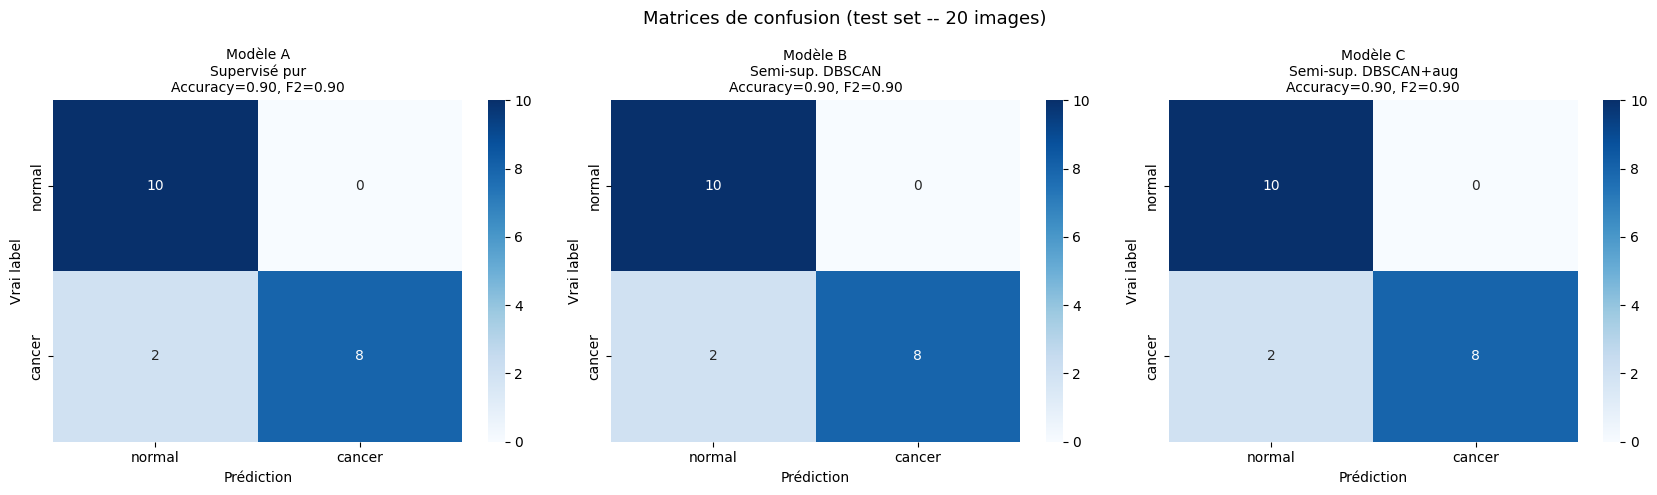

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Matrices de confusion (test set -- 20 images)", fontsize=13)

for ax, y_pred, acc, f2, title in zip(
    axes,
    [y_pred_A, y_pred_B, y_pred_C],
    [acc_A, acc_B, acc_C],
    [f2_A, f2_B, f2_C],
    ["Modèle A\nSupervisé pur", "Modèle B\nSemi-sup. DBSCAN", "Modèle C\nSemi-sup. DBSCAN+aug"]
):
    cm = confusion_matrix(labels_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["normal", "cancer"],
        yticklabels=["normal", "cancer"],
        ax=ax
    )
    ax.set_title(f"{title}\nAccuracy={acc:.2f}, F2={f2:.2f}", fontsize=10)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Vrai label")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

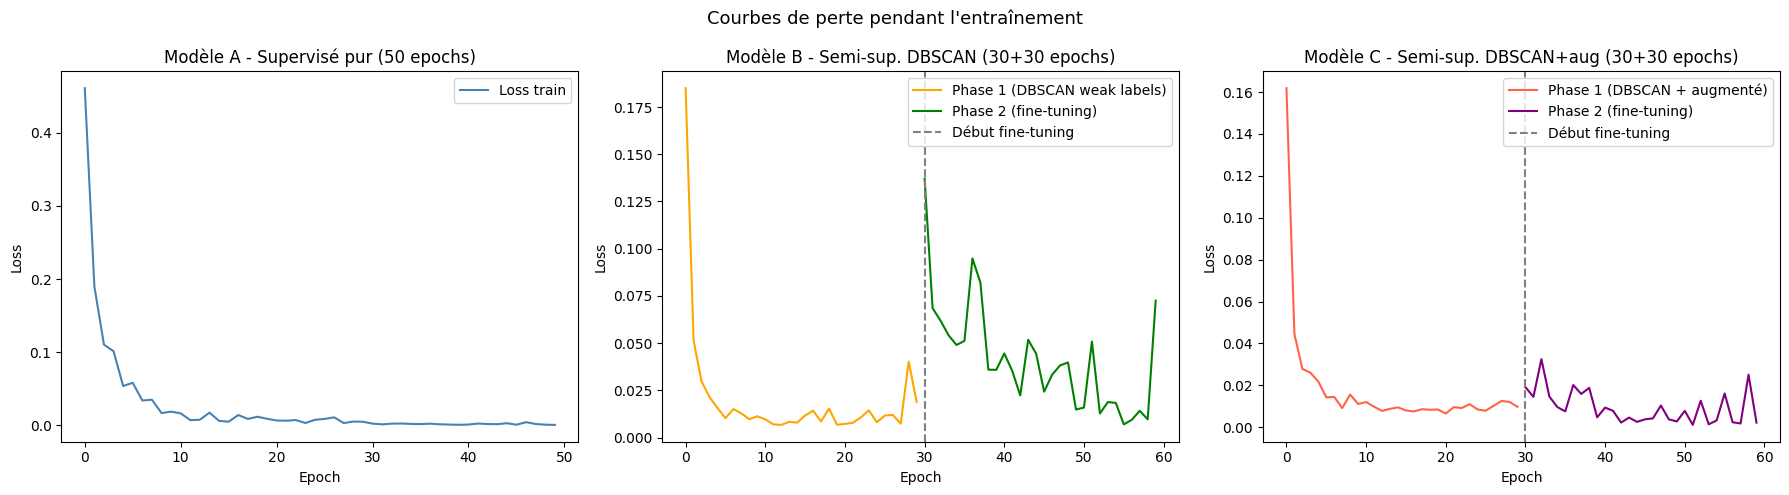

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes de perte pendant l'entraînement", fontsize=13)

# Modèle A
axes[0].plot(losses_A, color="steelblue", label="Loss train")
axes[0].set_title(f"Modèle A - Supervisé pur ({EPOCHS_A} epochs)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Modèle B -- DBSCAN weak labels
axes[1].plot(range(EPOCHS_WEAK), losses_B_phase1,
             color="orange", label="Phase 1 (DBSCAN weak labels)")
axes[1].plot(range(EPOCHS_WEAK, EPOCHS_WEAK + EPOCHS_STRONG), losses_B_phase2,
             color="green", label="Phase 2 (fine-tuning)")
axes[1].axvline(x=EPOCHS_WEAK, color="gray", linestyle="--", label="Début fine-tuning")
axes[1].set_title(f"Modèle B - Semi-sup. DBSCAN ({EPOCHS_WEAK}+{EPOCHS_STRONG} epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# Modèle C -- DBSCAN + augmentation
axes[2].plot(range(EPOCHS_WEAK), losses_C_phase1,
             color="tomato", label="Phase 1 (DBSCAN + augmenté)")
axes[2].plot(range(EPOCHS_WEAK, EPOCHS_WEAK + EPOCHS_STRONG), losses_C_phase2,
             color="purple", label="Phase 2 (fine-tuning)")
axes[2].axvline(x=EPOCHS_WEAK, color="gray", linestyle="--", label="Début fine-tuning")
axes[2].set_title(f"Modèle C - Semi-sup. DBSCAN+aug ({EPOCHS_WEAK}+{EPOCHS_STRONG} epochs)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 12b. Courbes ROC — comparaison des 3 modèles

La courbe ROC trace le **taux de vrais positifs (rappel/sensibilité)** en fonction du **taux de faux positifs (1 - spécificité)** pour tous les seuils de décision possibles.

- Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle
- La diagonale pointillée représente un classifieur aléatoire (AUC = 0.5)
- L'aire sous la courbe (AUC) résume la performance en un seul chiffre

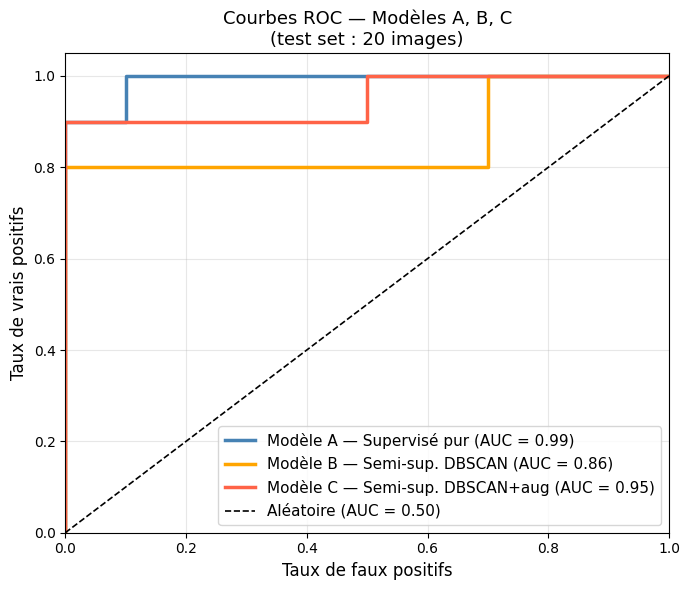

Courbes ROC sauvegardées dans results/roc_curves.png


In [22]:
fig, ax = plt.subplots(figsize=(7, 6))

models_roc = [
    (y_true_A, y_proba_A, f"Modèle A — Supervisé pur (AUC = {auc_A:.2f})",        "steelblue",  "-"),
    (y_true_B, y_proba_B, f"Modèle B — Semi-sup. DBSCAN (AUC = {auc_B:.2f})",     "orange",     "-"),
    (y_true_C, y_proba_C, f"Modèle C — Semi-sup. DBSCAN+aug (AUC = {auc_C:.2f})", "tomato",     "-"),
]

for y_true, y_proba, label, color, ls in models_roc:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5, label=label)

# Référence : classifieur aléatoire
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Aléatoire (AUC = 0.50)")

ax.set_xlabel("Taux de faux positifs", fontsize=12)
ax.set_ylabel("Taux de vrais positifs", fontsize=12)
ax.set_title("Courbes ROC — Modèles A, B, C\n(test set : 20 images)", fontsize=13)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Courbes ROC sauvegardées dans results/roc_curves.png")

## 13. Sauvegarde des modèles

In [21]:
# Sauvegarde des poids des trois modèles pour réutilisation ultérieure
torch.save(model_A.state_dict(), RESULTS_DIR / "model_A_supervised.pth")
torch.save(model_B.state_dict(), RESULTS_DIR / "model_B_semi_supervised_dbscan.pth")
torch.save(model_C.state_dict(), RESULTS_DIR / "model_C_semi_supervised_dbscan_aug.pth")
print("Modèles sauvegardés dans results/")

Modèles sauvegardés dans results/


## 14. Conclusions

### Process suivi

1. **Chargement** : features ResNet50 (1506 × 2048) + features augmentées (720 × 2048) + labels DBSCAN (étape 3) + test set (20 images)
2. **Standardisation** : StandardScaler entraîné sur les 1486 images non-test uniquement
3. **Modèle A** : MLP entraîné sur 80 images fortement labelisées -- Accuracy=0.90, F2=0.8974, ROC-AUC=0.98
4. **Modèle B** : MLP pré-entraîné sur 1486 images (DBSCAN weak labels) puis fine-tuné sur 80 -- Accuracy=0.85, F2=0.8440, ROC-AUC=0.94
5. **Modèle C** : MLP pré-entraîné sur ~2206 images (DBSCAN weak labels + 720 augmentées) puis fine-tuné sur 80 -- Accuracy=0.90, F2=0.8974, ROC-AUC=0.93
6. **Comparaison** :
   - **B vs A** : le modèle B est moins performant sur les 3 métriques (accuracy -0.05, F2 -0.0534, AUC -0.04). Les labels faibles issus du clustering DBSCAN introduisent du bruit que le fine-tuning sur 80 images ne corrige pas entièrement.
   - **C vs B** : l'ajout des 720 images augmentées en phase 1 compense ce bruit -- accuracy et F2 remontent exactement au niveau du modèle A (+0.05 et +0.0534 par rapport à B).
   - **C vs A** : accuracy et F2 identiques, mais ROC-AUC légèrement inférieur (0.93 vs 0.98). Les deux modèles classent correctement les mêmes images, mais le modèle A le fait avec une meilleure séparation de probabilité entre les deux classes.
   - Les trois modèles atteignent le même F2-score (0.8974). L'AUC est légèrement inférieure pour B et C (bruit des weak labels DBSCAN, ARI=0.30). Malgré cela, l'approche semi-supervisée reste justifiée : avec 80 images labelisées seulement, elle réduit le risque de sur-apprentissage en exposant le modèle à plus de variabilité visuelle.

### Choix des métriques
- **F2-score** (plutôt que F1) : donne deux fois plus de poids au rappel qu'à la précision -- réduit l'importance relative des FN, critique en détection de cancer.
- **ROC-AUC** : mesure la capacité du modèle à bien séparer les deux classes par rang de probabilité, indépendamment du seuil de décision à 0.5.